# 🎮 Personalized VALORANT Agent Recommendation System

## Notebook 01 — Exploratory Data Analysis

### Project Objective

The objective of this project is to develop a personalized machine-learning
system that recommends suitable VALORANT agents based on an individual player's
own Competitive match history.

This notebook analyzes my personal VALORANT gameplay history in order to
understand how my performance varies across different agents, maps, and
Agent × Map combinations.

The final system takes the current map as input and generates **role-aware
personalized agent recommendations**, returning up to **two agents per role**
based on patterns learned from my own previous matches.

The recommendation process is intended to consider factors such as:

- previous experience with each agent,
- historical performance with each agent,
- previous experience on the current map,
- historical Agent × Map performance,
- recent gameplay form,
- agent familiarity and usage frequency.

My dataset will be modeled independently from other players' datasets so that
the recommendations remain personalized to my own gameplay history.

This notebook focuses on the **Exploratory Data Analysis (EDA)** stage of the
project.

### Current Dataset

- Game Mode: Competitive
- Total Matches: 304
- Data Period: November 2024 to September 2026
- Dataset Source: My personal VALORANT Competitive match history
- Data Type: Tabular
- Total Original Features: 22

### Goals of This Notebook

1. Inspect the structure and overall quality of my Competitive match dataset.
2. Identify missing values, duplicate records, and unusual match entries.
3. Study the distribution of wins, losses, and draws.
4. Analyze which agents I play most frequently and measure my level of agent
   familiarity.
5. Analyze the distribution of matches across different VALORANT maps.
6. Examine my overall gameplay-performance statistics.
7. Compare my historical performance across different agents.
8. Compare my historical performance across different maps.
9. Analyze specific Agent × Map combinations to determine whether my performance
   with an agent changes depending on the map.
10. Identify sparse Agent × Map combinations where limited match history may make
    performance estimates unreliable.
11. Examine relationships between match statistics and match outcomes.
12. Detect unusual values, surrender matches, overtime matches, and other
    non-standard match endings.
13. Identify which existing variables can later be transformed into historical
    pre-match features without introducing data leakage.
14. Prepare the dataset for chronological feature engineering and personalized
    machine-learning modelling.

### Future Goal

The final goal is to build a personalized map-based VALORANT agent
recommendation system.

When the current map is known, the system evaluates agents I have historical
experience with and ranks them within their respective roles, returning up to
**two personalized candidate agents per role** when sufficient history exists.

The recommendation will be based only on information that would have been
available before the target match, including historical features such as:

- recent 5-match and 10-match form,
- previous agent usage and familiarity,
- previous win rate and performance with each agent,
- previous map experience and map performance,
- previous Agent × Map experience and performance,
- number of previous matches played with an agent,
- number of previous matches played on a map,
- recency and frequency of agent usage.

Current-match statistics such as K/D, ACS, DDΔ, kills, deaths, and final score
are not used directly for pre-match recommendations because they are only known
during or after the match.

Instead, historical versions of these statistics will be calculated using only
matches that occurred before each target match.

The recommendation model will therefore learn my individual gameplay profile
rather than producing the same agent ranking for every player.


In [160]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [161]:
DATA_PATH = Path("../data/competitive_matches.xlsx")

df = pd.read_excel(
    DATA_PATH,
    sheet_name="Matches",
    header=1,
    usecols="A:V"
)

df.head()

,Match id,Date,Map,Placement,Agent,Team Score,Opponent Score,Result,Win Flag,Score Margin,...,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ (Average Damage Delta per Round),HS% (Headshot Percentage),ACS (Average Combat Score),TRS (Tracker Score)
0,1,2024-11-07,Sunset,6th,Sage,8,13,Loss,0.0,-5,...,16,3,1.000000,0.761905,0.761905,0.142857,-11,0.10,210,578
1,2,2024-11-07,Split,9th,Clove,5,13,Loss,0.0,-8,...,9,2,0.777778,0.388889,0.500000,0.111111,-9,0.10,117,172
2,3,2024-11-08,Pearl,4th,Clove,13,10,Win,1.0,3,...,15,2,1.333333,0.869565,0.652174,0.086957,19,0.09,229,728
3,4,2024-11-08,Sunset,3rd,Sage,9,11,Loss,0.0,-2,...,15,6,0.933333,0.700000,0.750000,0.300000,11,0.05,237,475
4,5,2024-11-09,Haven,7th,Clove,4,13,Loss,0.0,-9,...,16,2,0.562500,0.529412,0.941176,0.117647,-51,0.10,163,146


In [162]:
df = df.rename(columns={
    "DDΔ (Average Damage Delta per Round)": "DDΔ",
    "HS% (Headshot Percentage)": "HS%",
    "ACS (Average Combat Score)": "ACS",
    "TRS (Tracker Score)": "TRS"
})

In [163]:
print("Number of matches:", df.shape[0])
print("Number of features:", df.shape[1])

print("\nColumns:\n")
for column in df.columns:
    print(column)

Number of matches: 304
Number of features: 22

Columns:

Match id
Date
Map
Placement
Agent
Team Score
Opponent Score
Result
Win Flag
Score Margin
Rounds Played
Kills
Deaths
Assists
K/D
Kills/Round
Deaths/Round
Assists/Round
DDΔ
HS%
ACS
TRS


In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Match id        304 non-null    int64         
 1   Date            304 non-null    datetime64[us]
 2   Map             304 non-null    str           
 3   Placement       304 non-null    str           
 4   Agent           304 non-null    str           
 5   Team Score      304 non-null    int64         
 6   Opponent Score  304 non-null    int64         
 7   Result          304 non-null    str           
 8   Win Flag        294 non-null    float64       
 9   Score Margin    304 non-null    int64         
 10  Rounds Played   304 non-null    int64         
 11  Kills           304 non-null    int64         
 12  Deaths          304 non-null    int64         
 13  Assists         304 non-null    int64         
 14  K/D             304 non-null    float64       
 15  Kills/Round     3

In [165]:
df.isnull().sum()

Match id           0
Date               0
Map                0
Placement          0
Agent              0
Team Score         0
Opponent Score     0
Result             0
Win Flag          10
Score Margin       0
Rounds Played      0
Kills              0
Deaths             0
Assists            0
K/D                0
Kills/Round        0
Deaths/Round       0
Assists/Round      0
DDΔ                0
HS%                0
ACS                0
TRS                0
dtype: int64

In [166]:
print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate Match id values:",
    df["Match id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate Match id values: 0


In [167]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

print(
    "Oldest match:",
    df["Date"].min()
)

print(
    "Newest match:",
    df["Date"].max()
)

datetime64[us]
Oldest match: 2024-11-07 00:00:00
Newest match: 2026-09-27 00:00:00


In [168]:
print("========================")
print("Maps:")
print(df["Map"].value_counts())
print("========================")
print("\nAgents:")
print(df["Agent"].value_counts())
print("========================")
print("\nResults:")
print(df["Result"].value_counts())

Maps:
Map
Haven       43
Ascent      41
Split       39
Lotus       39
Pearl       34
Sunset      25
Icebox      21
Abyss       17
Fracture    17
Bind        16
Breeze       5
Summit       4
Corrode      3
Name: count, dtype: int64

Agents:
Agent
Sage        164
Clove        59
Killjoy      30
Breach       17
Deadlock     11
Skye          9
Astra         6
Fade          5
Reyna         3
Name: count, dtype: int64

Results:
Result
Loss    152
Win     142
Draw     10
Name: count, dtype: int64


In [169]:
result_counts = df["Result"].value_counts()

print(result_counts)

Result
Loss    152
Win     142
Draw     10
Name: count, dtype: int64


In [170]:
result_percentages = (
    df["Result"]
    .value_counts(normalize=True)
    * 100
)

print(result_percentages.round(2))

Result
Loss    50.00
Win     46.71
Draw     3.29
Name: proportion, dtype: float64


In [171]:
df.describe()

,Match id,Date,Team Score,Opponent Score,Win Flag,Score Margin,Rounds Played,Kills,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ,HS%,ACS,TRS
count,304.00000,304,304.000000,304.000000,294.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,152.50000,2025-07-07 13:15:47.368421,9.953947,10.059211,0.482993,-0.105263,20.013158,11.128289,13.848684,5.230263,0.907263,0.559312,0.687562,0.259072,-28.500000,0.070625,159.713816,427.812500
min,1.00000,2024-11-07 00:00:00,0.000000,0.000000,0.000000,-13.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.133333,0.000000,-136.000000,0.000000,14.000000,100.000000
25%,76.75000,2025-03-08 00:00:00,7.000000,7.750000,0.000000,-6.000000,17.000000,7.000000,11.000000,3.000000,0.542424,0.375000,0.578441,0.153846,-58.000000,0.040000,112.000000,238.250000
50%,152.50000,2025-04-19 00:00:00,12.000000,13.000000,0.000000,-1.000000,20.000000,11.000000,14.000000,5.000000,0.766968,0.540064,0.695652,0.250000,-30.500000,0.060000,153.500000,417.500000
75%,228.25000,2025-07-24 12:00:00,13.000000,13.000000,1.000000,5.000000,23.000000,14.000000,17.000000,7.000000,1.129464,0.722222,0.809524,0.350735,-3.750000,0.090000,198.000000,587.500000
max,304.00000,2026-09-27 00:00:00,15.000000,15.000000,1.000000,13.000000,30.000000,32.000000,24.000000,13.000000,4.500000,1.391304,1.066667,0.750000,129.000000,0.330000,409.000000,976.000000
std,87.90146,NaN,3.851773,3.907737,0.500563,6.524043,4.201189,5.529398,4.481366,2.873506,0.611180,0.253628,0.171495,0.133090,45.310079,0.044639,66.247264,233.326839


In [172]:
print(df.columns.tolist())

['Match id', 'Date', 'Map', 'Placement', 'Agent', 'Team Score', 'Opponent Score', 'Result', 'Win Flag', 'Score Margin', 'Rounds Played', 'Kills', 'Deaths', 'Assists', 'K/D', 'Kills/Round', 'Deaths/Round', 'Assists/Round', 'DDΔ', 'HS%', 'ACS', 'TRS']


In [173]:
total_matches = len(df)

wins = (df["Result"] == "Win").sum()
losses = (df["Result"] == "Loss").sum()
draws = (df["Result"] == "Draw").sum()

win_rate = wins / total_matches

total_kills = df["Kills"].sum()
total_deaths = df["Deaths"].sum()

overall_kd = total_kills / total_deaths

average_acs = df["ACS"].mean()
average_hs = df["HS%"].mean()

print("=== OVERALL PERFORMANCE ===")

print(f"Matches: {total_matches}")
print(f"Wins: {wins}")
print(f"Losses: {losses}")
print(f"Draws: {draws}")

print(f"Win Rate: {win_rate:.2%}")
print(f"Overall K/D: {overall_kd:.2f}")
print(f"Average ACS: {average_acs:.2f}")
print(f"Average HS%: {average_hs:.2%}")

=== OVERALL PERFORMANCE ===
Matches: 304
Wins: 142
Losses: 152
Draws: 10
Win Rate: 46.71%
Overall K/D: 0.80
Average ACS: 159.71
Average HS%: 7.06%


**WIN VS LOSS VS DRAW**


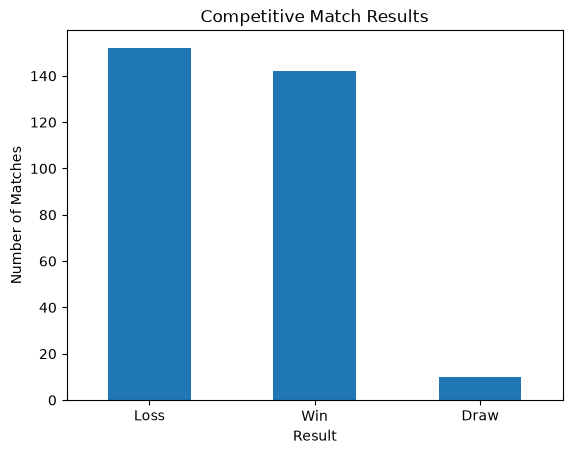

In [174]:
df["Result"].value_counts().plot(
    kind="bar",
    title="Competitive Match Results"
)

plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.show()

**MATCHES PLAYED BY AGENTS**


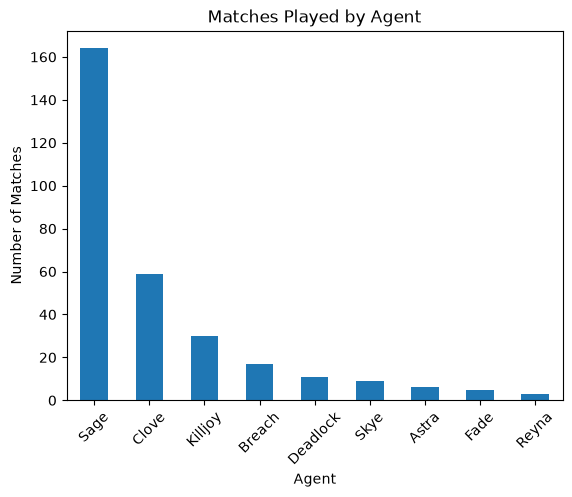

In [175]:
df["Agent"].value_counts().plot(
    kind="bar",
    title="Matches Played by Agent"
)

plt.xlabel("Agent")
plt.ylabel("Number of Matches")

plt.xticks(
    rotation=45
)

plt.show()

**MATCHES PLAYED ON MAPS**


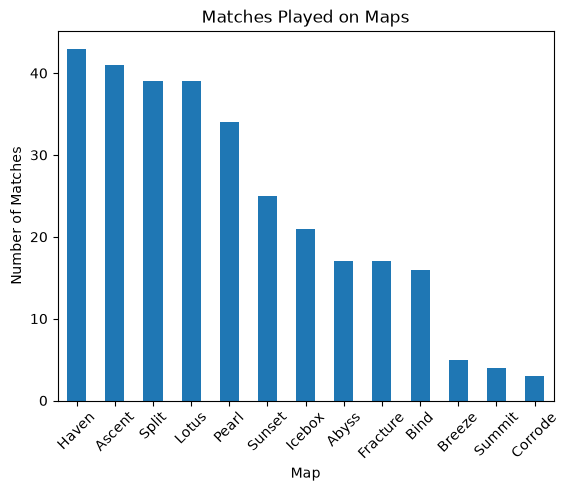

In [176]:
df["Map"].value_counts().plot(
    kind="bar",
    title="Matches Played on Maps"
)

plt.xlabel("Map")
plt.ylabel("Number of Matches")

plt.xticks(
    rotation=45
)

plt.show()

<!-- # Initial EDA Findings — Original Dataset

The initial EDA below describes the original dataset. `TRS` was later removed
from the revised role-aware dataset and is not used in the final machine-learning pipeline.


The Competitive dataset contains 294 matches recorded
between November 2024 and September 2026.

## Dataset Quality

- No duplicate matches were detected.
- Agent and map information is complete.
- Ten Win Flag values are missing because the corresponding
  matches were recorded as draws.
- Several matches have non-standard final scores, potentially
  representing early match termination and requiring further
  investigation.

## Match Outcomes

- Wins: 135
- Losses: 149
- Draws: 10

The Win/Loss distribution is reasonably balanced.

## Agent Distribution

The dataset is strongly dominated by Sage matches.
Agents such as Astra, Reyna, and Fade have much smaller
sample sizes and should therefore be interpreted cautiously.

## Performance

Overall K/D is approximately 0.80 and average ACS is
approximately 159.5.

Matches that were won show substantially higher average K/D
than lost matches.

## ML Considerations

Current-match performance variables such as K/D, ACS,
DDΔ and TRS are post-match variables and must not be used
directly for pre-match prediction.

Future modelling will instead use historical versions of
these features calculated only from matches played before
the target match. -->


## Performance by Agent

This section compares historical performance across the different
agents played in Competitive matches.

Because the number of matches played with each agent is different,
sample size must be considered when interpreting metrics such as
win rate and K/D.


In [177]:
agent_stats = (
    df.groupby("Agent")
    .agg(
        Matches=("Match id", "count"),
        Wins=("Win Flag", "sum"),
        Kills=("Kills", "sum"),
        Deaths=("Deaths", "sum"),
        Assists=("Assists", "sum"),
        Avg_ACS=("ACS", "mean"),
        Avg_HS=("HS%", "mean"),
        Avg_DD=("DDΔ", "mean")
    )
)

agent_stats["Win_Rate"] = (
    agent_stats["Wins"] / agent_stats["Matches"]
)

agent_stats["Overall_KD"] = (
    agent_stats["Kills"] / agent_stats["Deaths"]
)

agent_stats.sort_values(
    "Matches",
    ascending=False
).round(2)

,Matches,Wins,Kills,Deaths,Assists,Avg_ACS,Avg_HS,Avg_DD,Win_Rate,Overall_KD
Agent,,,,,,,,,,
Sage,164,74.0,1769,2199,975,155.79,0.07,-30.52,0.45,0.80
Clove,59,27.0,700,933,256,166.37,0.07,-36.71,0.46,0.75
Killjoy,30,19.0,362,389,132,169.57,0.07,-8.77,0.63,0.93
Breach,17,9.0,184,223,64,157.47,0.06,-22.94,0.53,0.83
Deadlock,11,2.0,119,151,33,163.36,0.06,-27.18,0.18,0.79
Skye,9,3.0,92,121,45,145.89,0.07,-38.67,0.33,0.76
Astra,6,5.0,59,79,34,142.17,0.12,-14.50,0.83,0.75
Fade,5,2.0,68,80,41,199.20,0.11,-8.20,0.40,0.85
Reyna,3,1.0,30,35,10,154.67,0.04,-21.67,0.33,0.86


## Performance by Map

This section compares my historical Competitive performance across
different VALORANT maps.

Metrics such as win rate, overall K/D, ACS and damage delta are used
to identify map-specific performance patterns.


In [178]:
map_stats = (
    df.groupby("Map")
    .agg(
        Matches=("Match id", "count"),
        Wins=("Win Flag", "sum"),
        Kills=("Kills", "sum"),
        Deaths=("Deaths", "sum"),
        Assists=("Assists", "sum"),
        Avg_ACS=("ACS", "mean"),
        Avg_HS=("HS%", "mean"),
        Avg_DD=("DDΔ", "mean")
    )
)

map_stats["Win_Rate"] = (
    map_stats["Wins"] / map_stats["Matches"]
)

map_stats["Overall_KD"] = (
    map_stats["Kills"] / map_stats["Deaths"]
)

map_stats.sort_values(
    "Matches",
    ascending=False
).round(2)

,Matches,Wins,Kills,Deaths,Assists,Avg_ACS,Avg_HS,Avg_DD,Win_Rate,Overall_KD
Map,,,,,,,,,,
Haven,43,23.0,494,597,214,163.30,0.07,-23.88,0.53,0.83
Ascent,41,20.0,483,537,226,175.05,0.07,-17.85,0.49,0.90
Lotus,39,14.0,431,527,202,160.10,0.07,-30.79,0.36,0.82
Split,39,23.0,408,506,207,148.85,0.07,-25.03,0.59,0.81
Pearl,34,16.0,330,476,185,139.12,0.07,-36.53,0.47,0.69
Sunset,25,8.0,303,377,134,174.20,0.07,-37.24,0.32,0.80
Icebox,21,9.0,231,310,120,155.48,0.09,-31.05,0.43,0.75
Fracture,17,11.0,165,211,75,136.29,0.05,-32.41,0.65,0.78
Abyss,17,8.0,209,254,86,171.06,0.06,-24.71,0.47,0.82


## Agent × Map Analysis

This section analyzes performance for specific Agent–Map combinations.

-to understand whether my performance changes depending on
which agent I play on a particular map because some Agent–Map combinations have very few matches, sample size
must be considered before interpreting win rate or performance metrics.


In [179]:
agent_map_stats = (
    df.groupby(["Map", "Agent"])
    .agg(
        Matches=("Match id", "count"),
        Wins=("Win Flag", "sum"),
        Kills=("Kills", "sum"),
        Deaths=("Deaths", "sum"),
        Assists=("Assists", "sum"),
        Avg_ACS=("ACS", "mean"),
        Avg_HS=("HS%", "mean"),
        Avg_DD=("DDΔ", "mean")
    )
    .reset_index()
)

agent_map_stats["Win_Rate"] = (
    agent_map_stats["Wins"] / agent_map_stats["Matches"]
)

agent_map_stats["Overall_KD"] = (
    agent_map_stats["Kills"] / agent_map_stats["Deaths"]
)

agent_map_stats.sort_values(
    "Matches",
    ascending=False
).head(20).round(2)

,Map,Agent,Matches,Wins,Kills,Deaths,Assists,Avg_ACS,Avg_HS,Avg_DD,Win_Rate,Overall_KD
58,Split,Sage,26,16.0,279,327,158,154.42,0.07,-23.96,0.62,0.85
45,Lotus,Sage,25,8.0,287,350,141,159.32,0.08,-32.56,0.32,0.82
33,Haven,Sage,23,9.0,226,299,117,148.91,0.07,-32.48,0.39,0.76
11,Ascent,Sage,22,11.0,226,271,122,157.73,0.08,-24.73,0.50,0.83
53,Pearl,Sage,18,7.0,174,227,110,143.56,0.07,-32.61,0.39,0.77
40,Icebox,Sage,14,6.0,150,216,93,156.71,0.07,-40.71,0.43,0.69
63,Sunset,Sage,11,5.0,152,161,78,189.45,0.05,-19.00,0.45,0.94
31,Haven,Clove,11,6.0,151,177,48,179.91,0.08,-27.00,0.55,0.85
61,Sunset,Clove,10,1.0,108,169,37,161.40,0.08,-64.20,0.10,0.64
28,Fracture,Sage,8,5.0,75,96,43,121.62,0.03,-40.50,0.62,0.78


## K/D Distribution

This section examines the distribution of K/D ratios across all
Competitive matches.

The purpose is to understand the typical range of K/D values,
identify unusually high or low performances, and observe whether
the distribution is concentrated around a particular range.


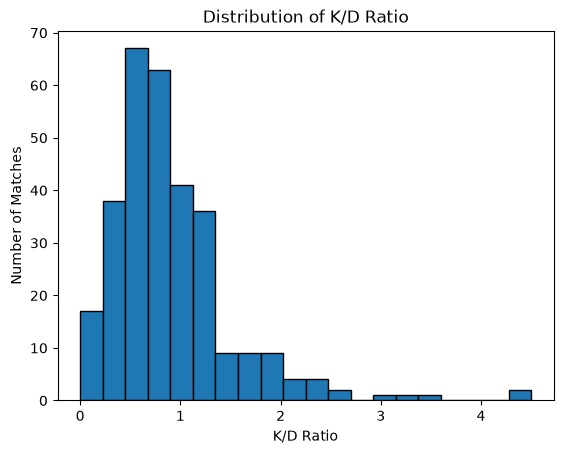

In [180]:
plt.hist(
    df["K/D"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of K/D Ratio")
plt.xlabel("K/D Ratio")
plt.ylabel("Number of Matches")

plt.show()

In [181]:
print("Average K/D:", round(df["K/D"].mean(), 2))
print("Median K/D:", round(df["K/D"].median(), 2))
print("Minimum K/D:", round(df["K/D"].min(), 2))
print("Maximum K/D:", round(df["K/D"].max(), 2))

Average K/D: 0.91
Median K/D: 0.77
Minimum K/D: 0.0
Maximum K/D: 4.5


## ACS Distribution

This section examines the distribution of Average Combat Score (ACS)
across all Competitive matches.

The goal is to understand the typical ACS range, identify unusually
high or low performances, and observe how combat performance is
distributed across the dataset.


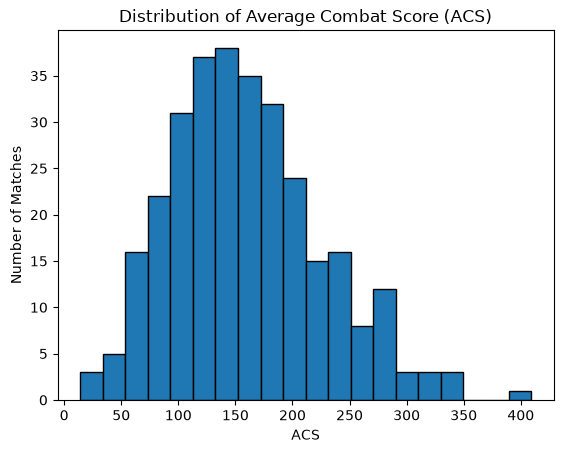

In [182]:
plt.hist(
    df["ACS"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Average Combat Score (ACS)")
plt.xlabel("ACS")
plt.ylabel("Number of Matches")

plt.show()

In [183]:
print("Average ACS:", round(df["ACS"].mean(), 2))
print("Median ACS:", round(df["ACS"].median(), 2))
print("Minimum ACS:", df["ACS"].min())
print("Maximum ACS:", df["ACS"].max())

Average ACS: 159.71
Median ACS: 153.5
Minimum ACS: 14
Maximum ACS: 409


## DDΔ Distribution

This section examines the distribution of Average Damage Delta per Round (DDΔ)
across all Competitive matches.

DDΔ represents the difference between damage dealt and damage received per round.

Positive DDΔ values indicate that more damage was dealt than received,
while negative values indicate that more damage was received than dealt.


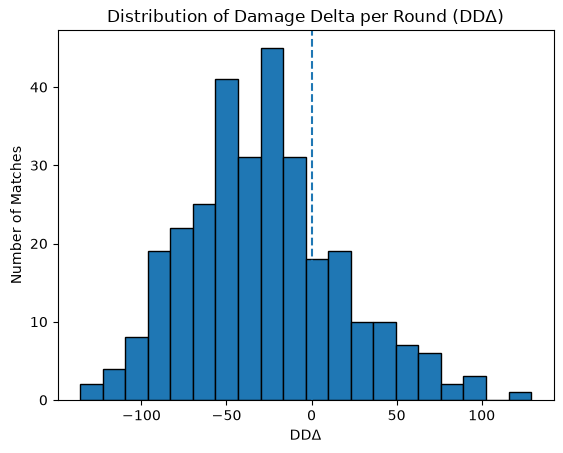

In [184]:
plt.hist(
    df["DDΔ"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Damage Delta per Round (DDΔ)")
plt.xlabel("DDΔ")
plt.ylabel("Number of Matches")

plt.show()

In [185]:
print("Average DDΔ:", round(df["DDΔ"].mean(), 2))
print("Median DDΔ:", round(df["DDΔ"].median(), 2))
print("Minimum DDΔ:", df["DDΔ"].min())
print("Maximum DDΔ:", df["DDΔ"].max())

Average DDΔ: -28.5
Median DDΔ: -30.5
Minimum DDΔ: -136
Maximum DDΔ: 129


## Wins vs Losses Comparison

This section compares performance metrics between matches that were won
and matches that were lost.

The purpose is to identify which performance statistics tend to differ
between wins and losses.

These relationships are descriptive and do not necessarily imply causation.


In [186]:
result_performance = (
    df.groupby("Result")
    .agg(
        Avg_KD=("K/D", "mean"),
        Avg_ACS=("ACS", "mean"),
        Avg_DD=("DDΔ", "mean"),
        Avg_Kills=("Kills", "mean"),
        Avg_Deaths=("Deaths", "mean"),
        Avg_Assists=("Assists", "mean"),
        Avg_TRS=("TRS", "mean")
    )
)

result_performance.round(2)

,Avg_KD,Avg_ACS,Avg_DD,Avg_Kills,Avg_Deaths,Avg_Assists,Avg_TRS
Result,,,,,,,
Draw,0.76,159.90,-38.00,15.30,20.10,8.20,424.20
Loss,0.68,154.87,-46.91,10.30,15.45,4.62,297.90
Win,1.16,164.89,-8.12,11.72,11.69,5.68,567.13


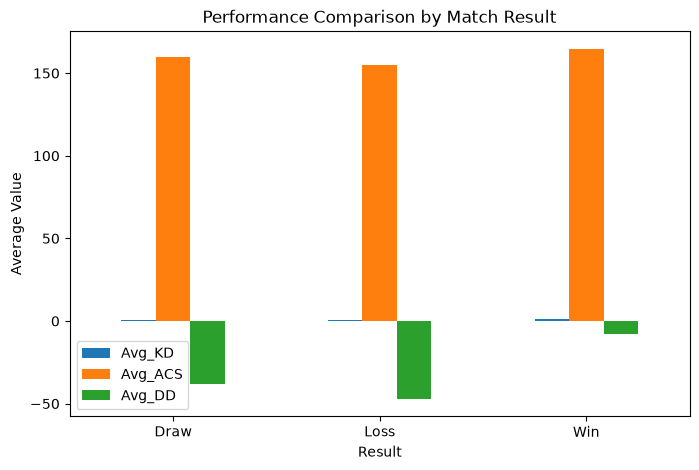

In [187]:
result_performance[
    ["Avg_KD", "Avg_ACS", "Avg_DD"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Performance Comparison by Match Result")
plt.xlabel("Result")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

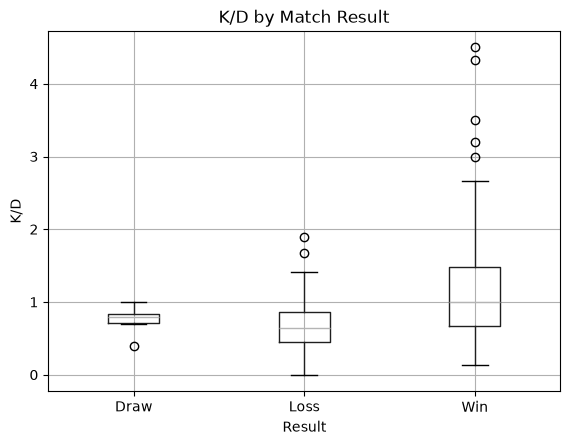

In [188]:
df.boxplot(
    column="K/D",
    by="Result"
)

plt.title("K/D by Match Result")
plt.suptitle("")
plt.xlabel("Result")
plt.ylabel("K/D")

plt.show()

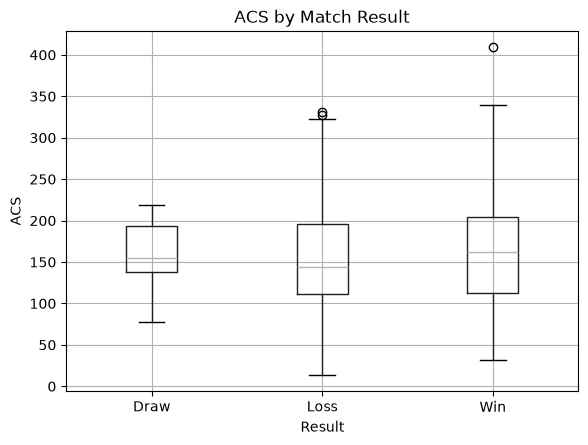

In [189]:
df.boxplot(
    column="ACS",
    by="Result"
)

plt.title("ACS by Match Result")
plt.suptitle("")
plt.xlabel("Result")
plt.ylabel("ACS")

plt.show()

## Correlation

This section examines the relationships between numerical features in
the Competitive match dataset.

Correlation values range from -1 to +1:

- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate little or no linear relationship.

Special attention is given to correlations with the Win Flag in order
to identify performance metrics that are associated with match outcomes.

Correlation does not imply causation.


In [190]:
numeric_columns = [
    "Win Flag",
    "Kills",
    "Deaths",
    "Assists",
    "K/D",
    "Kills/Round",
    "Deaths/Round",
    "Assists/Round",
    "DDΔ",
    "HS%",
    "ACS",
    "TRS"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix.round(2)

,Win Flag,Kills,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ,HS%,ACS,TRS
Win Flag,1.00,0.13,-0.43,0.19,0.39,0.15,-0.61,0.22,0.42,-0.00,0.07,0.57
Kills,0.13,1.00,0.19,0.21,0.57,0.88,-0.06,0.08,0.68,0.08,0.86,0.70
Deaths,-0.43,0.19,1.00,0.21,-0.53,-0.14,0.74,-0.05,-0.46,-0.02,-0.05,-0.37
Assists,0.19,0.21,0.21,1.00,-0.00,0.02,-0.08,0.92,0.11,-0.08,0.09,0.22
K/D,0.39,0.57,-0.53,-0.00,1.00,0.74,-0.62,0.07,0.83,0.14,0.65,0.79
Kills/Round,0.15,0.88,-0.14,0.02,0.74,1.00,-0.12,0.03,0.78,0.10,0.97,0.78
Deaths/Round,-0.61,-0.06,0.74,-0.08,-0.62,-0.12,1.00,-0.15,-0.56,-0.05,-0.01,-0.52
Assists/Round,0.22,0.08,-0.05,0.92,0.07,0.03,-0.15,1.00,0.16,-0.12,0.10,0.26
DDΔ,0.42,0.68,-0.46,0.11,0.83,0.78,-0.56,0.16,1.00,0.13,0.77,0.89
HS%,-0.00,0.08,-0.02,-0.08,0.14,0.10,-0.05,-0.12,0.13,1.00,0.04,0.06


In [191]:
win_correlations = (
    correlation_matrix["Win Flag"]
    .drop("Win Flag")
    .sort_values(ascending=False)
)

win_correlations.round(2)

TRS              0.57
DDΔ              0.42
K/D              0.39
Assists/Round    0.22
Assists          0.19
Kills/Round      0.15
Kills            0.13
ACS              0.07
HS%             -0.00
Deaths          -0.43
Deaths/Round    -0.61
Name: Win Flag, dtype: float64

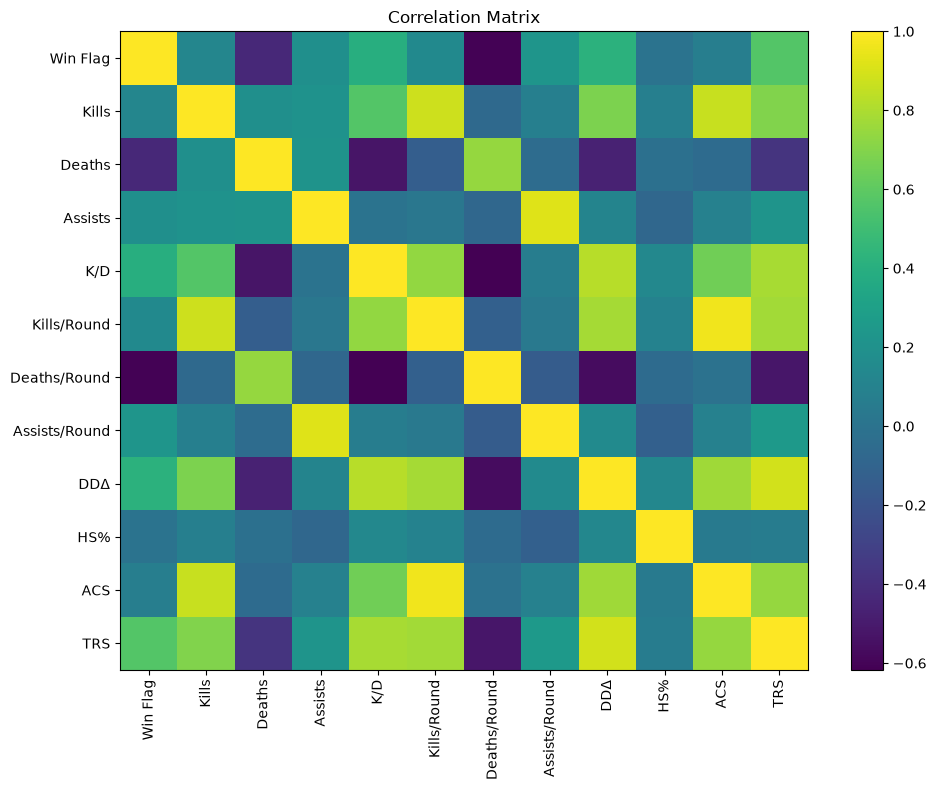

In [192]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## Outlier Analysis

This section investigates unusually high or low values in important
performance metrics such as K/D, ACS and DDΔ.

Outliers are examined to determine whether they represent valid extreme
performances or possible data-quality issues.

Outliers are not removed automatically.


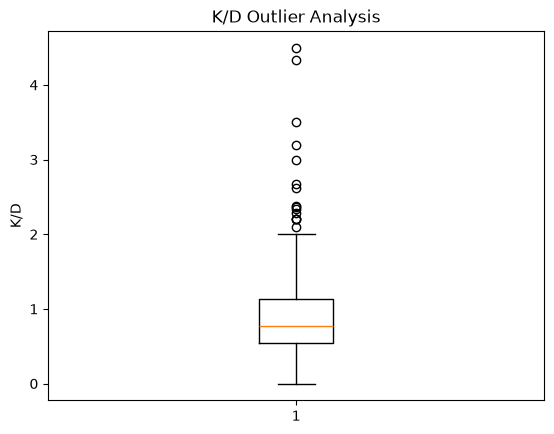

In [193]:
plt.boxplot(df["K/D"])

plt.title("K/D Outlier Analysis")
plt.ylabel("K/D")

plt.show()

Highest k/d matches


In [194]:
df.sort_values(
    "K/D",
    ascending=False
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
117,2025-03-30,Ascent,Sage,9,2,4.500000,182,65
139,2025-04-15,Ascent,Killjoy,13,3,4.333333,290,77
62,2025-02-24,Pearl,Sage,7,2,3.500000,128,45
255,2026-08-11,Ascent,Clove,16,5,3.200000,277,73
148,2025-04-18,Icebox,Astra,3,1,3.000000,81,13
285,2026-08-30,Haven,Sage,32,12,2.666667,409,129
250,2026-08-08,Sunset,Sage,21,8,2.625000,248,44
251,2026-08-08,Haven,Clove,19,8,2.375000,314,90
275,2026-08-27,Sunset,Sage,26,11,2.363636,302,84
162,2025-04-27,Split,Killjoy,21,9,2.333333,237,70


Lowest k/d matches


In [195]:
df.sort_values(
    "K/D",
    ascending=True
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
58,2025-02-22,Pearl,Deadlock,0,18,0.000000,14,-136
137,2025-04-12,Pearl,Killjoy,2,15,0.133333,32,-83
201,2025-06-20,Icebox,Sage,3,22,0.136364,47,-100
35,2025-01-08,Pearl,Sage,3,18,0.166667,46,-114
37,2025-01-11,Split,Sage,2,12,0.166667,69,-87
80,2025-03-11,Split,Sage,3,17,0.176471,74,-88
145,2025-04-16,Haven,Sage,2,11,0.181818,53,-82
47,2025-02-19,Fracture,Sage,2,11,0.181818,62,-113
225,2025-07-23,Ascent,Clove,3,16,0.187500,92,-81
166,2025-05-03,Pearl,Sage,3,16,0.187500,88,-81


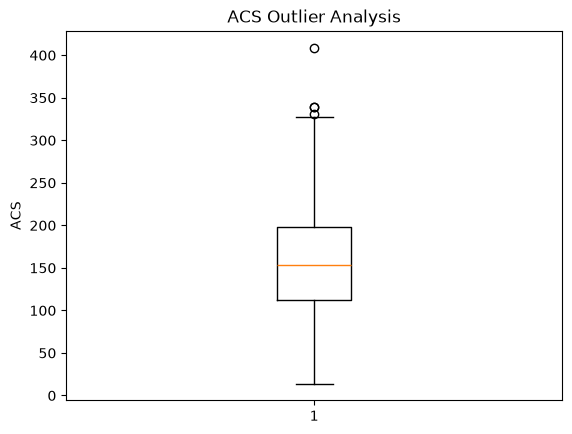

In [196]:
plt.boxplot(df["ACS"])

plt.title("ACS Outlier Analysis")
plt.ylabel("ACS")

plt.show()

In [197]:
df.sort_values(
    "ACS",
    ascending=False
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
285,2026-08-30,Haven,Sage,32,12,2.666667,409,129
274,2026-08-27,Haven,Sage,22,10,2.200000,339,60
127,2025-04-07,Haven,Killjoy,26,16,1.625000,339,102
271,2026-08-25,Haven,Sage,6,5,1.200000,331,21
273,2026-08-26,Lotus,Sage,25,15,1.666667,327,14
258,2026-08-12,Sunset,Sage,20,16,1.250000,322,38
251,2026-08-08,Haven,Clove,19,8,2.375000,314,90
275,2026-08-27,Sunset,Sage,26,11,2.363636,302,84
22,2024-12-03,Bind,Clove,28,23,1.217391,301,24
246,2025-08-29,Bind,Clove,14,16,0.875000,293,-19


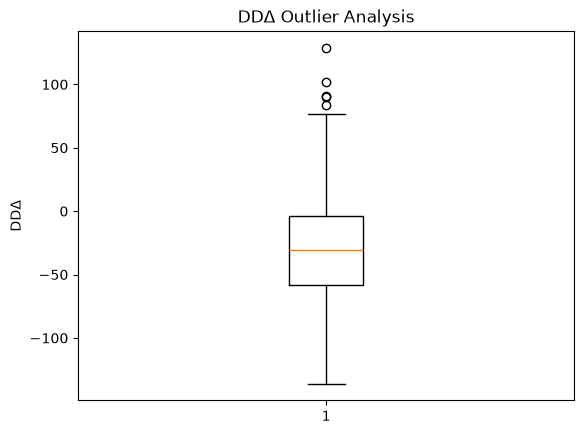

In [198]:
plt.boxplot(df["DDΔ"])

plt.title("DDΔ Outlier Analysis")
plt.ylabel("DDΔ")

plt.show()

In [199]:
df.sort_values(
    "DDΔ",
    ascending=False
)[
    [
        "Date",
        "Map",
        "Agent",
        "Kills",
        "Deaths",
        "K/D",
        "ACS",
        "DDΔ"
    ]
].head(10)

,Date,Map,Agent,Kills,Deaths,K/D,ACS,DDΔ
285,2026-08-30,Haven,Sage,32,12,2.666667,409,129
127,2025-04-07,Haven,Killjoy,26,16,1.625000,339,102
119,2025-03-30,Pearl,Breach,24,13,1.846154,289,91
251,2026-08-08,Haven,Clove,19,8,2.375000,314,90
275,2026-08-27,Sunset,Sage,26,11,2.363636,302,84
139,2025-04-15,Ascent,Killjoy,13,3,4.333333,290,77
255,2026-08-11,Ascent,Clove,16,5,3.200000,277,73
206,2025-06-23,Icebox,Sage,22,11,2.000000,261,71
162,2025-04-27,Split,Killjoy,21,9,2.333333,237,70
199,2025-06-20,Split,Sage,16,7,2.285714,258,70


## Match Score Validation and Match Ending Type

This section validates Competitive match scores and identifies how each
match ended.

Matches may end through:

- Regulation
- Overtime
- Overtime Draw
- Surrender

Some matches therefore have scores below the standard 13-round winning
threshold because one of the teams surrendered before the match was
completed normally.

For surrendered matches:

- If Team Score > Opponent Score, the opponent team surrendered.
- If Opponent Score > Team Score, my team surrendered.

These matches are valid observations and are retained in the dataset.


In [200]:
def classify_match_end(team_score, opponent_score, result):

    high = max(team_score, opponent_score)
    low = min(team_score, opponent_score)

    # Overtime Draw
    if result == "Draw":
        if team_score == opponent_score and team_score >= 13:
            return "Overtime Draw"

        return "Review"

    # Regulation ending
    if high == 13 and low <= 11:
        return "Regulation"

    # Overtime ending
    if high >= 14 and low >= 12 and (high - low) == 2:
        return "Overtime"

    # A Win/Loss with a non-standard final score
    # indicates that the match ended through surrender
    if result in ["Win", "Loss"]:
        return "Surrender"

    return "Review"

In [201]:
df["Match End Type"] = df.apply(
    lambda row: classify_match_end(
        row["Team Score"],
        row["Opponent Score"],
        row["Result"]
    ),
    axis=1
)

df["Match End Type"].value_counts()

Match End Type
Regulation       250
Overtime          24
Surrender         20
Overtime Draw     10
Name: count, dtype: int64

In [202]:
def surrendered_by(row):

    if row["Match End Type"] != "Surrender":
        return None

    if row["Result"] == "Win":
        return "Opponent Team"

    if row["Result"] == "Loss":
        return "My Team"

    return "Unknown"


df["Surrendered By"] = df.apply(
    surrendered_by,
    axis=1
)

In [203]:
df["Surrendered By"].value_counts()

Surrendered By
My Team          11
Opponent Team     9
Name: count, dtype: int64

In [204]:
df[
    df["Match End Type"] == "Surrender"
][
    [
        "Match id",
        "Date",
        "Map",
        "Agent",
        "Team Score",
        "Opponent Score",
        "Result",
        "Surrendered By"
    ]
]

,Match id,Date,Map,Agent,Team Score,Opponent Score,Result,Surrendered By
3,4,2024-11-08,Sunset,Sage,9,11,Loss,My Team
8,9,2024-11-10,Ascent,Sage,10,3,Win,Opponent Team
18,19,2024-11-24,Pearl,Reyna,3,11,Loss,My Team
27,28,2024-12-27,Ascent,Sage,7,7,Win,Opponent Team
30,31,2025-01-06,Split,Sage,1,8,Loss,My Team
54,55,2025-02-21,Bind,Sage,9,8,Win,Opponent Team
57,58,2025-02-22,Split,Sage,4,9,Loss,My Team
60,61,2025-02-23,Bind,Deadlock,3,10,Loss,My Team
91,92,2025-03-16,Ascent,Sage,0,6,Loss,My Team
95,96,2025-03-17,Ascent,Sage,2,6,Loss,My Team


# Updated Dataset: Role-Aware EDA

Following feedback on the initial dataset design, the raw match-history dataset
was revised to better support a role-aware agent recommendation system.

The following changes were made:

- `TRS (Tracker Score)` was removed from the dataset.
- A new categorical feature, `Role`, was added immediately after `Agent`.
- Each agent is mapped to one of four VALORANT roles:
  - Duelist
  - Controller
  - Initiator
  - Sentinel
- ACS is retained as a performance measure.

The agent determines the official role, while ACS is used to study how strongly
the player performs when playing agents belonging to each role.

The purpose of this update is to prevent the final recommendation system from
returning several agents from the same role. The final recommendation layer
evaluates agents within their respective roles and can return up to **two
personalized candidate agents per role**.

The earlier EDA is retained because it still describes the original match
history correctly. The following cells specifically analyze the revised,
role-aware dataset.


In [205]:
# ============================================================
# LOAD UPDATED ROLE-AWARE DATASET
# ============================================================

UPDATED_DATA_PATH = Path(
    "../data/updated/competitive_matches_role_updated.xlsx"
)

df_updated = pd.read_excel(
    UPDATED_DATA_PATH,
    sheet_name="Matches",
    header=1,
    usecols="A:V"
)


# Shorten metric names
df_updated = df_updated.rename(
    columns={
        "DDΔ (Average Damage Delta per Round)": "DDΔ",
        "HS% (Headshot Percentage)": "HS%",
        "ACS (Average Combat Score)": "ACS"
    }
)


# Basic type cleanup
df_updated["Date"] = pd.to_datetime(
    df_updated["Date"]
)

df_updated["K/D"] = pd.to_numeric(
    df_updated["K/D"],
    errors="coerce"
)

df_updated["ACS"] = pd.to_numeric(
    df_updated["ACS"],
    errors="coerce"
)


# Draws are not part of the binary Win/Loss target
df_updated.loc[
    df_updated["Result"] == "Draw",
    "Win Flag"
] = pd.NA


df_updated.head()

,Match id,Date,Map,Placement,Agent,Role,Team Score,Opponent Score,Result,Win Flag,...,Kills,Deaths,Assists,K/D,Kills/Round,Deaths/Round,Assists/Round,DDΔ,HS%,ACS
0,1,2024-11-07,Sunset,6th,Sage,Sentinel,8,13,Loss,0.0,...,16,16,3,1.000000,0.761905,0.761905,0.142857,-11,0.10,210
1,2,2024-11-07,Split,9th,Clove,Controller,5,13,Loss,0.0,...,7,9,2,0.777778,0.388889,0.500000,0.111111,-9,0.10,117
2,3,2024-11-08,Pearl,4th,Clove,Controller,13,10,Win,1.0,...,20,15,2,1.333333,0.869565,0.652174,0.086957,19,0.09,229
3,4,2024-11-08,Sunset,3rd,Sage,Sentinel,9,11,Loss,0.0,...,14,15,6,0.933333,0.700000,0.750000,0.300000,11,0.05,237
4,5,2024-11-09,Haven,7th,Clove,Controller,4,13,Loss,0.0,...,9,16,2,0.562500,0.529412,0.941176,0.117647,-51,0.10,163


In [206]:
# ============================================================
# UPDATED DATASET VERIFICATION
# ============================================================

print(
    "Updated dataset shape:",
    df_updated.shape
)

print(
    "\nUpdated columns:"
)

for column in df_updated.columns:
    print(column)


print(
    "\nTRS present:",
    "TRS" in df_updated.columns
)

print(
    "Role present:",
    "Role" in df_updated.columns
)

print(
    "\nMissing Role values:",
    df_updated["Role"].isna().sum()
)

print(
    "\nRoles found:"
)

print(
    df_updated["Role"]
    .value_counts()
)

Updated dataset shape: (304, 22)

Updated columns:
Match id
Date
Map
Placement
Agent
Role
Team Score
Opponent Score
Result
Win Flag
Score Margin
Rounds Played
Kills
Deaths
Assists
K/D
Kills/Round
Deaths/Round
Assists/Round
DDΔ
HS%
ACS

TRS present: False
Role present: True

Missing Role values: 0

Roles found:
Role
Sentinel      205
Controller     65
Initiator      31
Duelist         3
Name: count, dtype: int64


In [207]:
# ============================================================
# ROLE DISTRIBUTION
# ============================================================

role_distribution = (
    df_updated["Role"]
    .value_counts()
    .rename_axis("Role")
    .reset_index(
        name="Matches"
    )
)


role_distribution[
    "Usage (%)"
] = (
    role_distribution["Matches"]
    / len(df_updated)
    * 100
)


role_distribution[
    "Usage (%)"
] = (
    role_distribution[
        "Usage (%)"
    ]
    .round(2)
)


role_distribution

,Role,Matches,Usage (%)
0,Sentinel,205,67.43
1,Controller,65,21.38
2,Initiator,31,10.20
3,Duelist,3,0.99


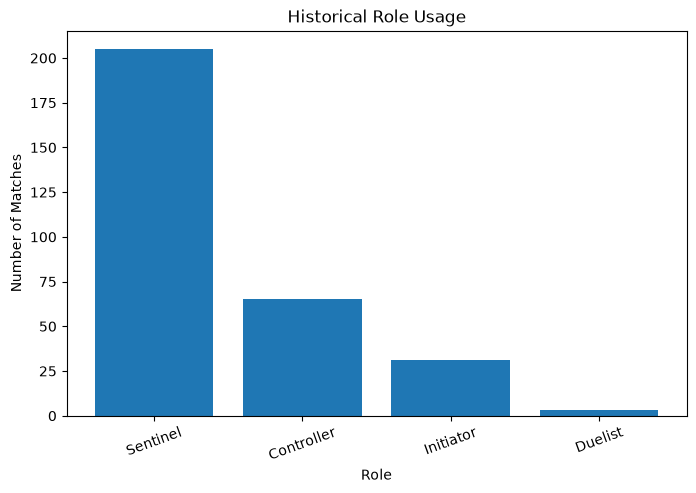

In [208]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    role_distribution["Role"],
    role_distribution["Matches"]
)

plt.title(
    "Historical Role Usage"
)

plt.xlabel(
    "Role"
)

plt.ylabel(
    "Number of Matches"
)

plt.xticks(
    rotation=20
)

plt.show()

In [209]:
# ============================================================
# ROLE PERFORMANCE SUMMARY
# ============================================================

role_summary = (
    df_updated
    .groupby("Role")
    .agg(
        Matches=(
            "Match id",
            "count"
        ),

        Wins=(
            "Result",
            lambda x:
            (x == "Win").sum()
        ),

        Losses=(
            "Result",
            lambda x:
            (x == "Loss").sum()
        ),

        Draws=(
            "Result",
            lambda x:
            (x == "Draw").sum()
        ),

        Average_ACS=(
            "ACS",
            "mean"
        ),

        Median_ACS=(
            "ACS",
            "median"
        ),

        Average_KD=(
            "K/D",
            "mean"
        )
    )
)


role_summary[
    "Win Rate (%)"
] = (
    role_summary["Wins"]
    /
    (
        role_summary["Wins"]
        + role_summary["Losses"]
    )
    * 100
)


role_summary[
    "Usage (%)"
] = (
    role_summary["Matches"]
    / len(df_updated)
    * 100
)


role_summary = (
    role_summary
    .round(2)
    .sort_values(
        "Matches",
        ascending=False
    )
)


role_summary

,Matches,Wins,Losses,Draws,Average_ACS,Median_ACS,Average_KD,Win Rate (%),Usage (%)
Role,,,,,,,,,
Sentinel,205,95,104,6,158.21,148.0,0.93,47.74,67.43
Controller,65,32,31,2,164.14,163.0,0.86,50.79,21.38
Initiator,31,14,15,2,160.84,165.0,0.85,48.28,10.20
Duelist,3,1,2,0,154.67,157.0,0.85,33.33,0.99


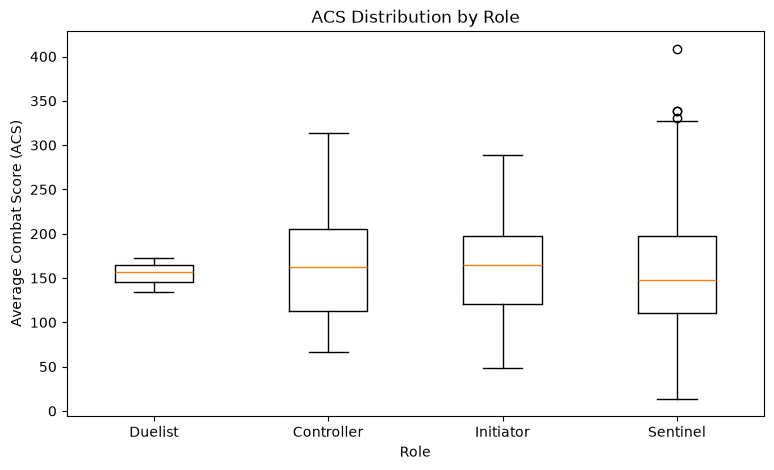

In [210]:
# ============================================================
# ACS DISTRIBUTION BY ROLE
# ============================================================

role_order = [
    "Duelist",
    "Controller",
    "Initiator",
    "Sentinel"
]


acs_by_role = [
    df_updated.loc[
        df_updated["Role"] == role,
        "ACS"
    ].dropna()
    for role in role_order
]


plt.figure(
    figsize=(9, 5)
)

plt.boxplot(
    acs_by_role,
    tick_labels=role_order
)

plt.title(
    "ACS Distribution by Role"
)

plt.xlabel(
    "Role"
)

plt.ylabel(
    "Average Combat Score (ACS)"
)

plt.show()

In [211]:
# ============================================================
# AGENT × ROLE PERFORMANCE
# ============================================================

agent_role_summary = (
    df_updated
    .groupby(
        [
            "Role",
            "Agent"
        ]
    )
    .agg(
        Matches=(
            "Match id",
            "count"
        ),

        Wins=(
            "Result",
            lambda x:
            (x == "Win").sum()
        ),

        Losses=(
            "Result",
            lambda x:
            (x == "Loss").sum()
        ),

        Average_ACS=(
            "ACS",
            "mean"
        ),

        Average_KD=(
            "K/D",
            "mean"
        )
    )
    .reset_index()
)


agent_role_summary[
    "Win Rate (%)"
] = (
    agent_role_summary["Wins"]
    /
    (
        agent_role_summary["Wins"]
        + agent_role_summary["Losses"]
    )
    * 100
)


agent_role_summary = (
    agent_role_summary
    .round(2)
    .sort_values(
        by=[
            "Role",
            "Matches"
        ],
        ascending=[
            True,
            False
        ]
    )
)


agent_role_summary

,Role,Agent,Matches,Wins,Losses,Average_ACS,Average_KD,Win Rate (%)
1,Controller,Clove,59,27,30,166.37,0.83,47.37
0,Controller,Astra,6,5,1,142.17,1.17,83.33
2,Duelist,Reyna,3,1,2,154.67,0.85,33.33
3,Initiator,Breach,17,9,8,157.47,0.86,52.94
5,Initiator,Skye,9,3,5,145.89,0.82,37.50
4,Initiator,Fade,5,2,2,199.20,0.88,50.00
8,Sentinel,Sage,164,74,84,155.79,0.91,46.84
7,Sentinel,Killjoy,30,19,11,169.57,1.06,63.33
6,Sentinel,Deadlock,11,2,9,163.36,0.85,18.18


### Historical Role-Level Agent Usage

The following table is descriptive only and should not be interpreted as the
final recommendation output.

It shows the two most frequently used historical agents within each role,
together with their historical ACS and win rate.

The final recommendation system will use the trained machine-learning model
rather than selecting agents purely from usage frequency or ACS.


In [212]:
# ============================================================
# MOST-USED AGENTS WITHIN EACH ROLE
# ============================================================

top_used_agents_by_role = (
    agent_role_summary
    .sort_values(
        [
            "Role",
            "Matches"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Role",
        group_keys=False
    )
    .head(2)
)


top_used_agents_by_role[
    [
        "Role",
        "Agent",
        "Matches",
        "Average_ACS",
        "Win Rate (%)"
    ]
]

,Role,Agent,Matches,Average_ACS,Win Rate (%)
1,Controller,Clove,59,166.37,47.37
0,Controller,Astra,6,142.17,83.33
2,Duelist,Reyna,3,154.67,33.33
3,Initiator,Breach,17,157.47,52.94
5,Initiator,Skye,9,145.89,37.50
8,Sentinel,Sage,164,155.79,46.84
7,Sentinel,Killjoy,30,169.57,63.33


# Initial EDA Findings — Original Dataset

The initial EDA below describes the original dataset. `TRS` was later removed
from the revised role-aware dataset and is not used in the final machine-learning pipeline.


The exploratory data analysis was performed on **304 personal VALORANT Competitive matches**
recorded between **7 November 2024 and 30 September 2026**.

## Dataset Quality

- The dataset contains **304 matches and 22 original features**.
- No duplicate rows or duplicate Match IDs were detected.
- Agent, map, score, and performance-statistic fields are complete.
- The `Win Flag` column contains **10 missing values**, corresponding to the 10 drawn matches rather than missing data.
- Match dates were successfully converted into chronological datetime values.
- Final-score analysis identified:
  - **250 Regulation matches**
  - **24 Overtime matches**
  - **20 Surrendered matches**
  - **10 Overtime Draws**
- Among surrendered matches, **11 were surrendered by my team** and **9 by the opponent team**.

One initially unusual match ended at a score of **7–7**. Inspection of the
original match history confirmed that the opponent team surrendered, so the
match was corrected from a Draw to a Win and classified as a Surrender.

This observation also demonstrated that the final score alone cannot always
identify which team surrendered. The recorded match result is therefore used
when identifying the surrendering team.

Surrendered matches are treated as valid Competitive observations rather than
erroneous score records.

## Match Outcome Distribution

The 304 matches consist of:

- **142 Wins**
- **152 Losses**
- **10 Draws**

The overall recorded win rate is approximately **46.71%**.

Wins and losses remain reasonably balanced, which is useful for future binary
classification. Drawn matches are retained for exploratory analysis but are
excluded from the binary Win/Loss modelling subset.

## Agent Distribution

The dataset is strongly dominated by a small number of frequently played agents.

The most frequently played agents are:

- **Sage: 164 matches**
- **Clove: 59 matches**
- **Killjoy: 30 matches**
- **Breach: 17 matches**

Several agents have much smaller sample sizes, including Astra, Reyna, and Fade.
Their performance statistics should therefore be interpreted cautiously.

Among agents with comparatively larger sample sizes:

- Sage has a historical win rate of approximately **45%**
- Clove has a historical win rate of approximately **46%**
- Killjoy has a historical win rate of approximately **63%**
- Breach has a historical win rate of approximately **53%**

Raw win rates should not be interpreted as proof that one agent is inherently
better because the number of matches, maps played, time period, and other match
conditions differ.

## Map Distribution

The most frequently played maps include:

- **Haven: 43 matches**
- **Ascent: 41 matches**
- **Split: 39 matches**
- **Lotus: 39 matches**
- **Pearl: 34 matches**

Some newer or less frequently encountered maps contain much smaller sample sizes.

Among the better represented maps:

- Split has a historical win rate of approximately **59%**
- Haven has a historical win rate of approximately **53%**
- Ascent has a historical win rate of approximately **49%**
- Lotus has a historical win rate of approximately **36%**

These results indicate that performance may differ across maps and support the
inclusion of map-related historical features in later modelling.

## Agent × Map Patterns

Performance also varies across specific Agent–Map combinations.

Some of the combinations with the largest sample sizes are:

- Sage on Split: **26 matches**, approximately **62% win rate**
- Sage on Lotus: **25 matches**, approximately **32% win rate**
- Sage on Haven: **23 matches**, approximately **39% win rate**
- Sage on Ascent: **22 matches**, approximately **50% win rate**
- Sage on Pearl: **18 matches**, approximately **39% win rate**

These results show why agent and map should not only be analyzed independently.
Their interaction may contain useful information for the final personalized
agent-recommendation system.

However, Agent–Map combinations with only a few observations must be interpreted
cautiously because extreme win rates from small samples may not be reliable.

## Overall Performance

Across the complete Competitive dataset:

- Overall aggregated K/D is approximately **0.80**
- Mean per-match K/D is approximately **0.91**
- Median per-match K/D is approximately **0.77**
- Average ACS is approximately **159.71**
- Average Headshot Percentage is approximately **7.06%**
- Average DDΔ is approximately **-28.50**

The per-match K/D ranges from:

- Minimum: **0.00**
- Maximum: **4.50**

ACS ranges from **14 to 409**, while DDΔ ranges from **-136 to +129**.

These extreme observations appear to represent unusually strong or weak matches
rather than automatically indicating incorrect data, so they are retained for
further analysis.

## Wins vs Losses — Original Dataset

Clear descriptive differences were observed between wins and losses.

Average performance in wins:

- K/D: approximately **1.16**
- ACS: approximately **164.89**
- DDΔ: approximately **-8.12**
- Kills: approximately **11.72**
- Deaths: approximately **11.69**
- Assists: approximately **5.68**
- TRS: approximately **567.13**

Average performance in losses:

- K/D: approximately **0.68**
- ACS: approximately **154.87**
- DDΔ: approximately **-46.91**
- Kills: approximately **10.30**
- Deaths: approximately **15.45**
- Assists: approximately **4.62**
- TRS: approximately **297.90**

This suggests that stronger combat-performance statistics are associated with
winning in this dataset.

The TRS values above are retained only as part of the initial EDA. `TRS` was
removed from the revised role-aware dataset and is not used by the final model.

These relationships are descriptive and should not be interpreted as evidence
of causation.

## Updated Role-Aware EDA Findings

The revised dataset contains the same historical matches as the original
dataset, but `TRS` has been removed and a new `Role` variable has been added.

The updated data shows a highly personalized role distribution.

- **Sentinel** is the most frequently played role, accounting for approximately
  **67%** of recorded matches.
- **Controller** is the second most frequently played role at approximately
  **21%**.
- Initiator usage is considerably lower.
- Duelist history is extremely limited, so Duelist performance estimates should
  be interpreted cautiously.
- Sage alone accounts for more than half of the recorded match history.

The ACS-by-role analysis provides an additional performance signal. However,
ACS does not determine an agent's role. The agent determines the role, while
historical ACS helps describe the player's performance within that role.

These findings support extending the feature-engineering stage with historical
role-level features such as role experience, role win rate, role ACS, and role
usage frequency.

## Initial Correlation Findings — Original Dataset

These correlation values were calculated during the initial EDA using the original dataset.
`TRS` was subsequently removed from the revised dataset and is not used in the final
feature-engineering or modelling pipeline.


Among the numerical variables, the strongest observed correlations with
`Win Flag` include:

### Positive Correlations

- TRS: approximately **+0.57**
- DDΔ: approximately **+0.42**
- K/D: approximately **+0.39**
- Assists/Round: approximately **+0.22**
- Assists: approximately **+0.19**

### Negative Correlations

- Deaths: approximately **-0.43**
- Deaths/Round: approximately **-0.61**

This indicates that matches with higher TRS, DDΔ, and K/D tend to be associated
with wins, while higher death-related values tend to be associated with losses.

Again, correlation represents association rather than causation.

## Important Machine-Learning Consideration

Variables describing the current match, such as:

- K/D
- ACS
- DDΔ
- Kills
- Deaths
- Assists
- Team Score
- Opponent Score
- Score Margin
- Match End Type

are only known during or after the match has already been played.

Therefore, these variables must **not** be used directly as predictors in a
model intended to make recommendations or predictions before a match, as doing
so would introduce **data leakage**.

Instead, historical feature engineering creates variables using only
information available before each target match, such as:

- Recent 5-match win rate
- Recent 10-match win rate
- Recent K/D
- Recent ACS
- Previous performance with the selected agent
- Previous performance on the selected map
- Previous Agent × Map performance
- Number of previous matches played with an agent
- Number of previous matches played on a map
- Number of previous matches played with an agent on a specific map
- Agent usage frequency
- Agent recency and familiarity
- Previous role match count
- Previous role win rate
- Previous role K/D
- Previous role ACS
- Role usage frequency

## EDA Conclusion

The dataset is sufficiently structured and informative to proceed with
historical feature engineering and personalized machine-learning modelling.

The analysis suggests that **recent performance, agent experience, map
experience, and Agent × Map interaction** are promising areas for feature
engineering.

Following EDA, the dataset is cleaned and transformed into leakage-free
historical features so that every training observation uses only information
that would have been available before the corresponding match.

These features are used to train player-specific models and generate
**role-aware personalized recommendations**, with up to **two candidate agents
per role** for a selected map.
